# Download the prerequisites
1. Tensorflow
2. Numpy
3. Matplotlib
4. Gradio
5. Sklearn
6. Seaborn

In [3]:
%pip install tensorflow
%pip install numpy
%pip install matplotlib
%pip install Gradio
%pip install scikit-learn
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# DATA ACQUISITION
## Step 1: Load the Datasets

## Rules
1. Do not skip the codes
2. Run the code in-order

### legend:
#### data_dir = directory of the data / data path
#### train_ds = means train Data set
#### validation_ds = means Validation Dataset

In [4]:
import tensorflow as tf

data_dir = "cat_breeds"
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset="training",
    seed=123,
    image_size=(180, 180),
    batch_size=32
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(180, 180),
    batch_size=32
)

Found 1349 files belonging to 10 classes.
Using 1080 files for training.
Found 1349 files belonging to 10 classes.
Using 269 files for validation.


# Data Exploration

In [5]:
#print the shape of the loaded data
# Grab one batch from the training set
for images, labels in train_ds.take(1):
    print("Train batch X shape (images):", images.shape)
    print("Train batch y shape (labels):", labels.shape)

# Grab one batch from the validation set
for images, labels in validation_ds.take(1):
    print("Validation batch X shape (images):", images.shape)
    print("Validation batch y shape (labels):", labels.shape)

Train batch X shape (images): (32, 180, 180, 3)
Train batch y shape (labels): (32,)
Validation batch X shape (images): (32, 180, 180, 3)
Validation batch y shape (labels): (32,)


In [6]:
#Print the class names
print("Cat breeds:", train_ds.class_names)
#Print the number of classes
print("Number of cat breeds:", len(train_ds.class_names))

Cat breeds: ['abyssinian', 'bengal', 'birman', 'british_shorthair', 'maine_coon', 'oriental_shorthair', 'persian', 'siamese', 'sphynx', 'turkish_van']
Number of cat breeds: 10


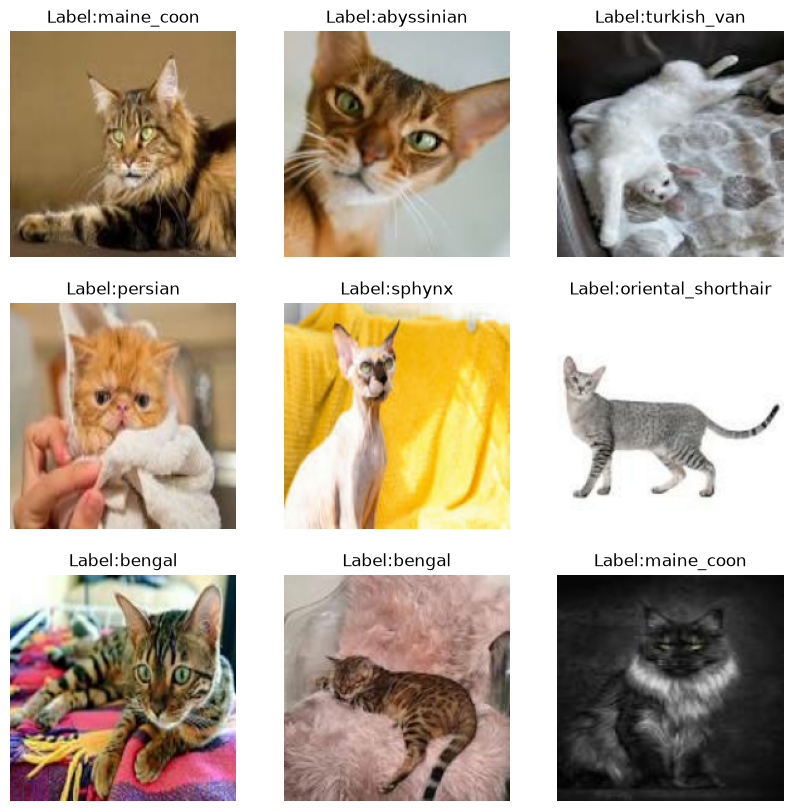

In [7]:
import matplotlib.pyplot as plt
import numpy as np

#display the first 9 images
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(
            f"Label:{train_ds.class_names[labels[i]]}"
        )
        plt.axis('off')
plt.show()


# Step 2: Data Reprocessing

# Model Creation

### dito niyo i te train yong model like:
### scaling, zooming, flipping, etc.

In [8]:
import keras
from keras import layers, models

class_names = train_ds.class_names

# load MobileNetV2 model
base_model = keras.applications.MobileNetV2(
    input_shape=(180, 180, 3),
    include_top=False,
    weights="imagenet"
)

#freeze the base_model(pretrained model)
base_model.trainable = False

model = models.Sequential([
    # Input shape: height, width, color channels
    layers.Input(shape=(180, 180, 3)),

    # Augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.Rescaling(1./127.5, offset=-1),

    base_model,
    # Feature layers (Convolutional Backbones)(reverted from 64, 128, 256, 512 to 32, 64, 128, 256)
    ###layers.Conv2D(32, (3, 3), activation='relu'),
    ##layers.MaxPooling2D((2, 2)),
    
    ##layers.Conv2D(64, (3, 3), activation='relu'),
    ##layers.MaxPooling2D((2, 2)),
    
    ##layers.Conv2D(128, (3, 3), activation='relu'),
    ##layers.MaxPooling2D((2, 2)),

    ##layers.Conv2D(256, (3, 3), activation='relu'),
    ##layers.MaxPooling2D((2, 2)),
    
    # Flatten features into a 1D vector
    # layers.Flatten(),
    # Pooling & Regularization (Collapses 2D maps into 1D vector of 256 features)
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'), # Hidden Dense Layer
    layers.Dropout(0.5),

    # Classification head
    layers.Dense(len(class_names), activation="softmax") #output layer with 10 units for the 1 classes
])

#compiling the model
model.compile(optimizer='adam',
              loss= "sparse_categorical_crossentropy",
              metrics = ['accuracy'])

model.summary()


C:\Users\acer\AppData\Local\Temp\ipykernel_11720\3601770001.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 180, 180, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Training the Model

In [9]:
history = model.fit(train_ds, validation_data= validation_ds, epochs= 35)


Epoch 1/35


c:\Users\acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


34/34 ━━━━━━━━━━━━━━━━━━━━ 22s 511ms/step - accuracy: 0.3546 - loss: 2.0090 - val_accuracy: 0.7026 - val_loss: 1.1629
Epoch 2/35
34/34 ━━━━━━━━━━━━━━━━━━━━ 15s 440ms/step - accuracy: 0.5833 - loss: 1.2369 - val_accuracy: 0.7175 - val_loss: 0.8678
Epoch 3/35
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 488ms/step - accuracy: 0.6611 - loss: 1.0058 - val_accuracy: 0.8104 - val_loss: 0.7230
Epoch 4/35
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 523ms/step - accuracy: 0.7241 - loss: 0.8339 - val_accuracy: 0.7955 - val_loss: 0.6475
Epoch 5/35
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 483ms/step - accuracy: 0.7389 - loss: 0.7612 - val_accuracy: 0.8067 - val_loss: 0.6153
Epoch 6/35
34/34 ━━━━━━━━━━━━━━━━━━━━ 15s 453ms/step - accuracy: 0.7713 - loss: 0.7053 - val_accuracy: 0.8141 - val_loss: 0.5969
Epoch 7/35
34/34 ━━━━━━━━━━━━━━━━━━━━ 15s 452ms/step - accuracy: 0.7731 - loss: 0.6741 - val_accuracy: 0.8253 - val_loss: 0.5760
Epoch 8/35
34/34 ━━━━━━━━━━━━━━━━━━━━ 15s 437ms/step - accuracy: 0.8028 - loss: 0.6094 - val_accuracy: 0.817

# Visualize the Training History

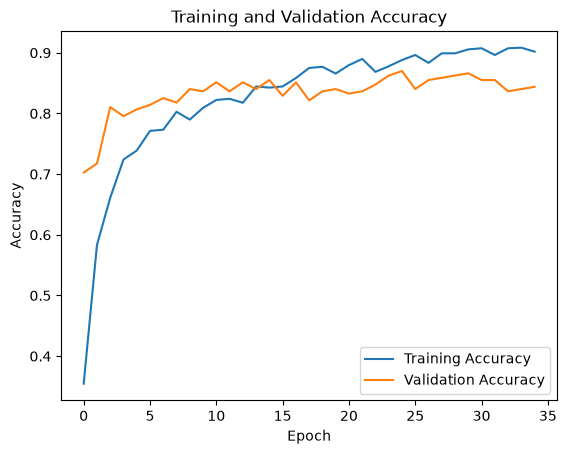

In [10]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

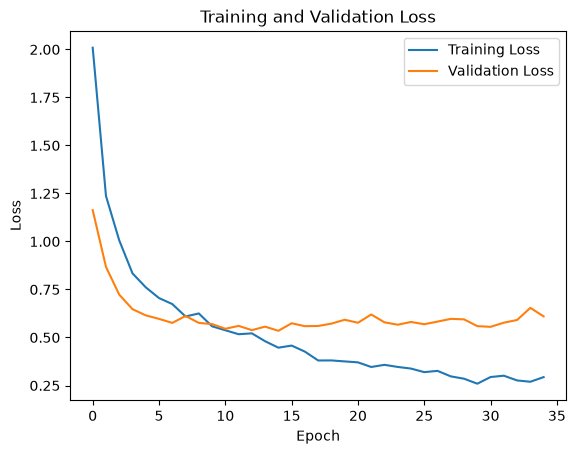

In [11]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Predictions

In [12]:
# Generate predictions
predictions = model.predict(train_ds)
# Print the shape of the predictions
print("Predictions shape:", predictions.shape)

34/34 ━━━━━━━━━━━━━━━━━━━━ 14s 366ms/step
Predictions shape: (1080, 10)


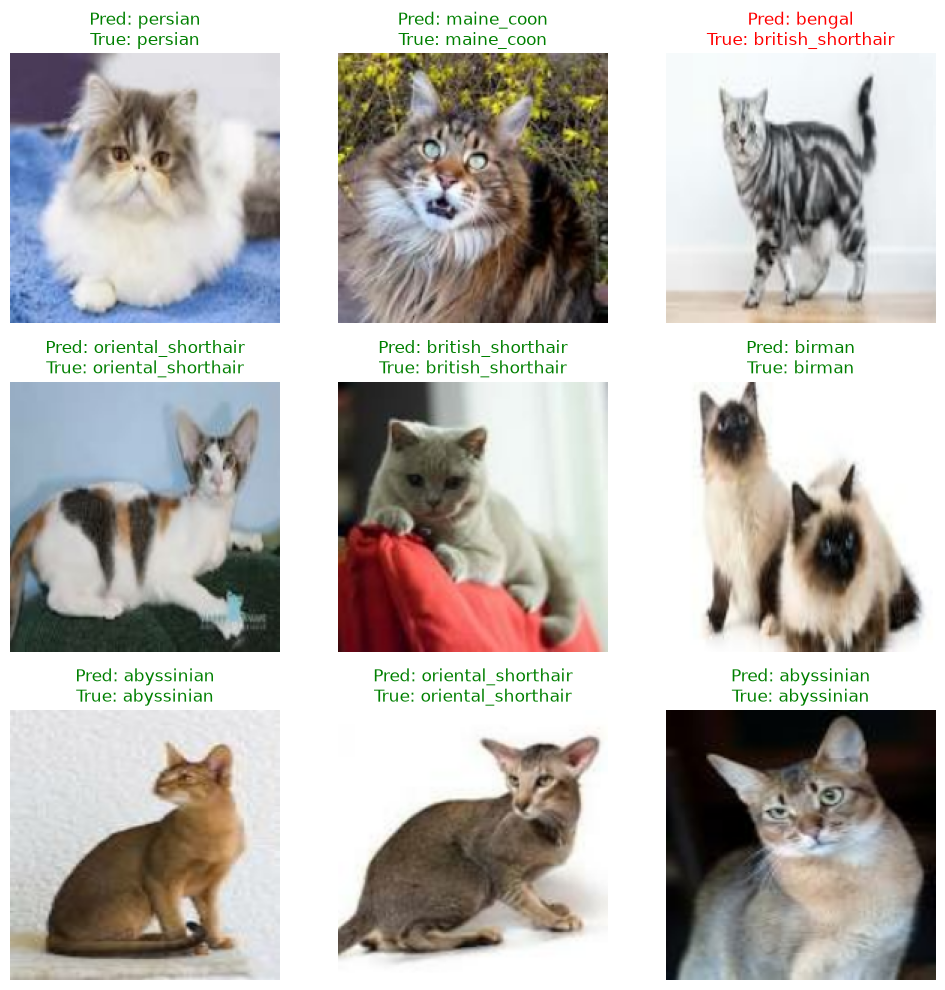

In [13]:
import os
import matplotlib.pyplot as plt
import numpy as np

class_names = sorted(os.listdir("cat_breeds"))
# 1. Grab one batch (32 images and their true labels)
for images, labels in validation_ds.take(1):
    # 2. Predict on this single batch
    batch_predictions = model.predict(images, verbose=0)
    
    # 3. Plot the first 9 images from this batch
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        
        # Display the image
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # Determine labels
        predicted_label = class_names[np.argmax(batch_predictions[i])]
        actual_label = class_names[labels[i].numpy()]
        
        # Green title if correct, Red if wrong
        color = "green" if predicted_label == actual_label else "red"
        
        plt.title(f"Pred: {predicted_label}\nTrue: {actual_label}", color=color)
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()
    break


# Model evaluation

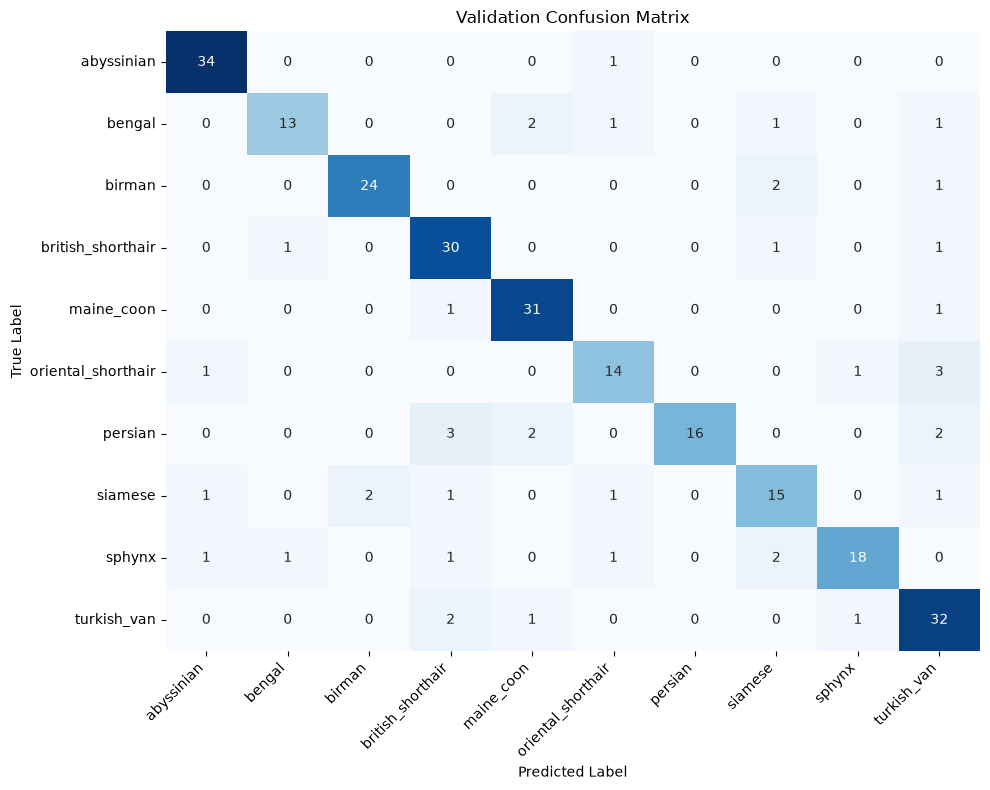

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Extract true labels and predictions from the validation set
true_labels = []
predicted_classes = []

for images, labels in validation_ds:
    preds = model.predict(images, verbose=0)
    predicted_classes.extend(np.argmax(preds, axis=1))
    true_labels.extend(labels.numpy())

# Convert to numpy arrays
true_labels = np.array(true_labels)
predicted_classes = np.array(predicted_classes)

# 2. Compute the confusion matrix
cm = confusion_matrix(true_labels, predicted_classes)

# 3. Plot using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Validation Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelBinarizer
# 1. Gather all validation probabilities and true labels
val_probs = []
val_labels = []

for images, labels in validation_ds:
    # Get raw logits from the model
    logits = model.predict(images, verbose=0)
    # Convert logits into valid probabilities (0.0 to 1.0)
    probs = tf.nn.softmax(logits).numpy()
    
    val_probs.extend(probs)
    val_labels.extend(labels.numpy())

val_probs = np.array(val_probs)
val_labels = np.array(val_labels)
# Convert true labels to one-hot encoding for ROC AUC calculation
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(val_labels)

# Calculate ROC AUC for each class
roc_auc_scores = roc_auc_score(y_test_bin, val_probs, average=None)

# Print the ROC AUC scores for each class
for i, score in enumerate(roc_auc_scores):
    print(f"ROC AUC for class {i}: {score:.4f}")

# Calculate macro-average ROC AUC
macro_roc_auc = roc_auc_score(y_test_bin, val_probs, average='macro')
print(f"\nMacro-average ROC AUC: {macro_roc_auc:.4f}")

ROC AUC for class 0: 0.9916
ROC AUC for class 1: 0.9845
ROC AUC for class 2: 0.9824
ROC AUC for class 3: 0.9809
ROC AUC for class 4: 0.9819
ROC AUC for class 5: 0.9421
ROC AUC for class 6: 0.9684
ROC AUC for class 7: 0.9760
ROC AUC for class 8: 0.9667
ROC AUC for class 9: 0.9711

Macro-average ROC AUC: 0.9746


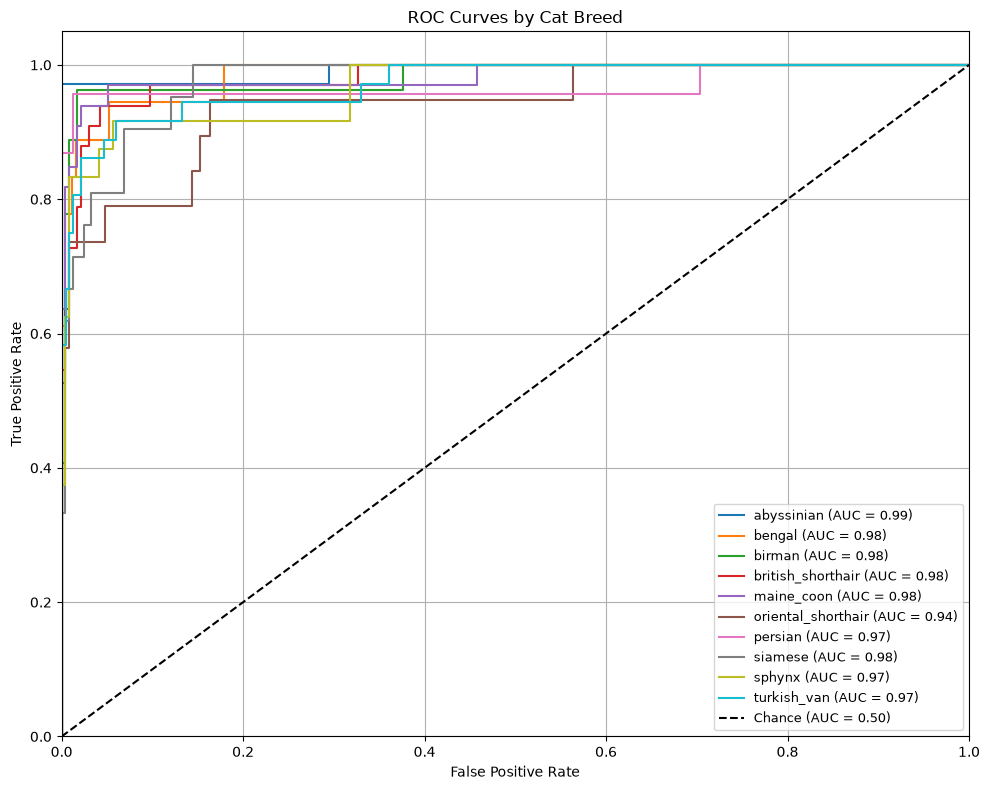

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import auc, roc_curve
from sklearn.preprocessing import LabelBinarizer

# 1. One-hot encode the validation labels
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(val_labels)

# 2. Plot ROC curves for all 10 cat breeds
plt.figure(figsize=(10, 8))

for i in range(10):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], val_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

# 3. Formatting
plt.plot([0, 1], [0, 1], "k--", label="Chance (AUC = 0.50)")
plt.title("ROC Curves by Cat Breed")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

# Deployment

In [17]:
# Convert the trained Keras model to a TensorFlow Lite model
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TensorFlow Lite model
with open("cat_breed_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Model saved as cat_breed_model.tflite")

INFO:tensorflow:Assets written to: C:\Users\acer\AppData\Local\Temp\tmp2jy55uif\assets


INFO:tensorflow:Assets written to: C:\Users\acer\AppData\Local\Temp\tmp2jy55uif\assets


Saved artifact at 'C:\Users\acer\AppData\Local\Temp\tmp2jy55uif'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2129566620496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2129615145488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2129615143568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2129565879568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2129615145872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2129615144912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2129615146256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2129615147024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2129615146640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2129615145296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2

# Gradio



In [ ]:
import tensorflow as tf
import numpy as np
import gradio as gr
from PIL import Image

# Load the TFLite model
interpreter = tf.lite.Interpreter(
    model_path="cat_breed_model.tflite"
)

interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Get the cat breed class names
class_names = train_ds.class_names


def classify_image(image):

    # Convert the image to a PIL Image
    img_pil = Image.fromarray(image.astype("uint8"))

    # Resize the image to the same size used during training
    img_pil = img_pil.resize((180, 180))

    # Convert the image to a NumPy array
    img = np.array(img_pil).astype("float32")

    # Make sure the image has 3 color channels
    if img.shape[-1] == 4:
        img = img[:, :, :3]

    # Add batch dimension
    img = np.expand_dims(img, axis=0)

    # Set the input tensor
    interpreter.set_tensor(
        input_details[0]["index"],
        img
    )

    # Run inference
    interpreter.invoke()

    # Get the output
    output_data = interpreter.get_tensor(
        output_details[0]["index"]
    )

    # Remove the batch dimension
    scores = np.squeeze(output_data)

    # Create the predictions dictionary
    predictions = {}

    for i in range(len(class_names)):
        predictions[class_names[i]] = float(scores[i])

    return predictions


# Create the Gradio interface
image_input = gr.Image(
    image_mode="RGB"
)

output_text = gr.Label(
    num_top_classes=5
)

gr.Interface(
    fn=classify_image,
    inputs=image_input,
    outputs=output_text,
    title="Cat Breed Image Classifier",
    description="Upload an image of a cat to classify its breed."
).launch(debug=True)

c:\Users\acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Created dataset file at: .gradio\flagged\dataset1.csv
